In [39]:
import pandas as pd

final_data2 = pd.read_csv("../data/final.csv")
final_data_trait = pd.read_csv("../data/final.csv")

/opt/anaconda3/lib/python3.13/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


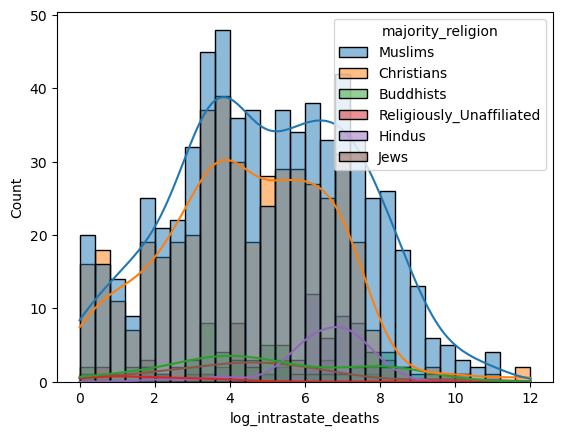

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

final_data2['log_intrastate_deaths'] = np.log(final_data2['intrastate_deaths'])

sns.histplot(
    data=final_data2,
    x="log_intrastate_deaths",
    hue="majority_religion",
    bins=30,
    kde=True
)

plt.show()

In [11]:
region_conflict = (
    final_data2
    .groupby(
        ["Region", "state-sponsored religion index"]
    )["intrastate_deaths"]
    .median()
    .reset_index()
)

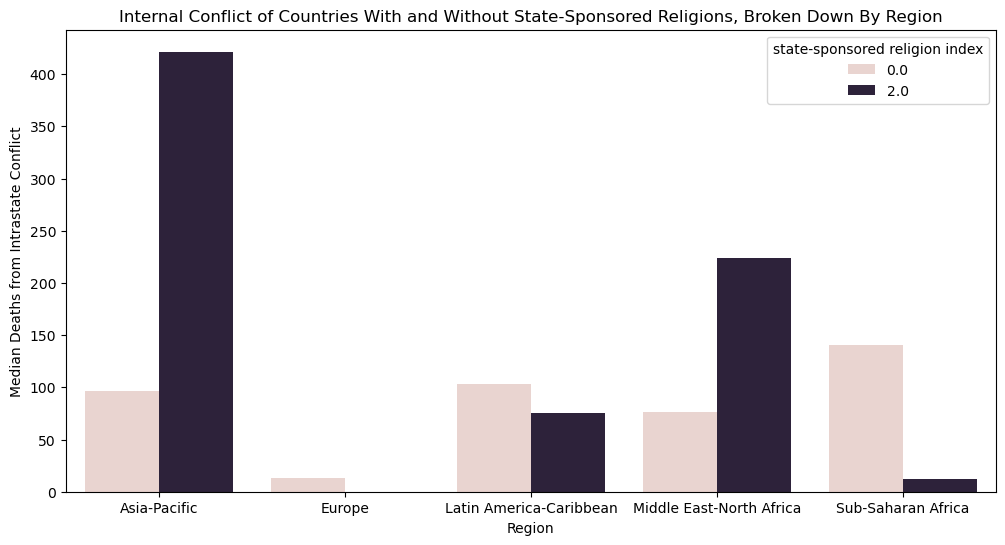

In [13]:
plt.figure(figsize=(12,6))

sns.barplot(
    data = region_conflict,
    x = "Region",
    y = "intrastate_deaths",
    hue = "state-sponsored religion index"
)

plt.xlabel("Region")
plt.ylabel("Median Deaths from Intrastate Conflict")
plt.title("Internal Conflict of Countries With and Without State-Sponsored Religions, Broken Down By Region")

plt.show()

In [14]:
final_data2.groupby(
    ["Region", "state-sponsored religion index"]
).size()

Region                    state-sponsored religion index
Asia-Pacific              0.0                               254
                          2.0                                98
Europe                    0.0                                52
                          2.0                                 1
Latin America-Caribbean   0.0                                94
                          2.0                                 2
Middle East-North Africa  0.0                                26
                          2.0                               212
Sub-Saharan Africa        0.0                               377
                          2.0                                15
dtype: int64

In [28]:
filtered_by_region = final_data2[
    ~final_data2["Region"].isin([
        "Europe",
        "Latin America-Caribbean"
    ])
]

final_data3 = (
    filtered_by_region
    .groupby(["Region", "state-sponsored religion index"])
    ["intrastate_deaths"]
    .median()
    .reset_index()
)

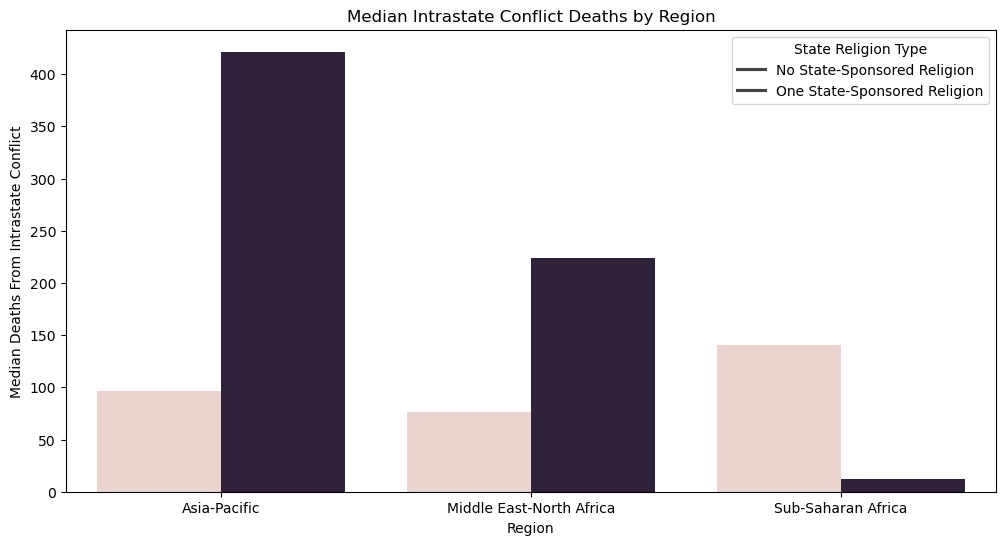

In [38]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=final_data3,
    x="Region",
    y="intrastate_deaths",
    hue="state-sponsored religion index"
)

plt.ylabel("Median Deaths From Intrastate Conflict")
plt.xlabel("Region")
plt.title(
    "Median Intrastate Conflict Deaths by Region"
)

plt.legend(
    title="State Religion Type",
    labels=[
        "No State-Sponsored Religion",
        "One State-Sponsored Religion"
    ]
)
plt.show()

In [14]:
# potentially go into literature and do more
# with breakdown of religions and what makes
# up the different religions

In [41]:
final_data_trait["log_intrastate_deaths"] = np.log1p(
    final_data_trait["intrastate_deaths"]
)

trait_cols = [
    "hierarchy",
    "exclusivity",
    "collectivism",
    "political_theology",
    "pluralism_tolerance"
]

trait_correlations = (
    final_data_trait[trait_cols + ["log_intrastate_deaths"]]
    .corr()["log_intrastate_deaths"]
    .drop("log_intrastate_deaths")
    .sort_values()
)

trait_correlations

pluralism_tolerance   -0.104902
hierarchy             -0.000560
exclusivity           -0.000560
political_theology     0.099889
collectivism           0.139680
Name: log_intrastate_deaths, dtype: float64

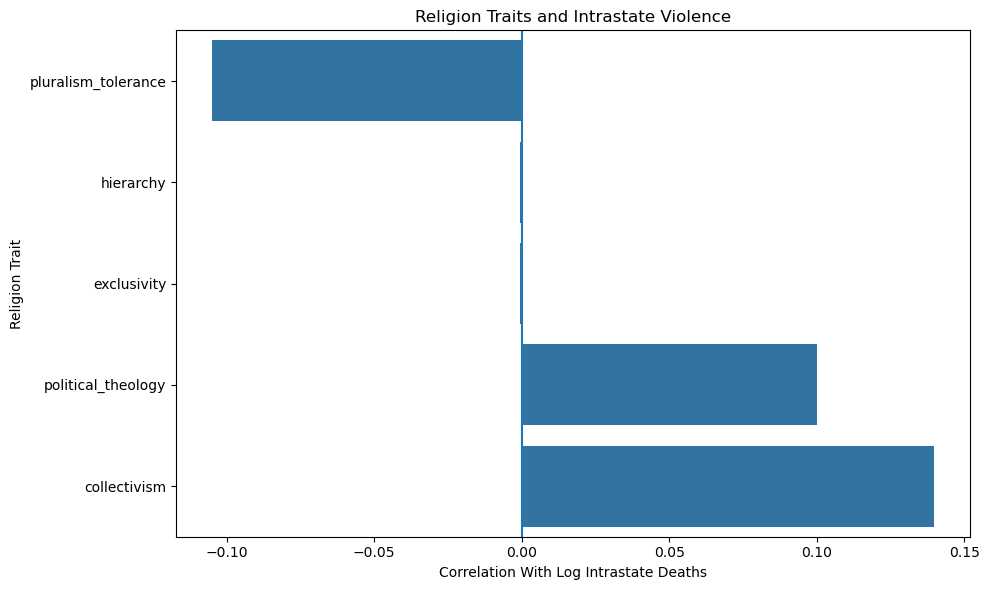

In [42]:
corr_df = trait_correlations.reset_index()
corr_df.columns = ["religion_trait", "correlation_with_violence"]

plt.figure(figsize=(10,6))

sns.barplot(
    data=corr_df,
    x="correlation_with_violence",
    y="religion_trait"
)

plt.axvline(0)
plt.xlabel("Correlation With Log Intrastate Deaths")
plt.ylabel("Religion Trait")
plt.title("Religion Traits and Intrastate Violence")

plt.tight_layout()
plt.show()

NameError: name 'religion_traits' is not defined

In [45]:
conflict_rate = (
    final_data2
    .groupby(["Region", "state-sponsored religion index"])["intrastate_conflict"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(12,6))

sns.barplot(
    data=conflict_rate,
    x="Region",
    y="intrastate_conflict",
    hue="state-sponsored religion index"
)

plt.ylabel("Share of Country-Years With Intrastate Conflict")
plt.xlabel("Region")
plt.title("Intrastate Conflict Occurrence by Region and State Religion Type")
plt.xticks(rotation=45, fontsize=8)
plt.tight_layout()
plt.show()

KeyError: 'Column not found: intrastate_conflict'